In [2]:
import pandas as pd

df = pd.read_csv("credit_card_customers.csv")
df.head()

,age,income,transactions,credit_limit,avg_spent,payment_delay,churn
0,56,147595,33,16378,2489,28,1
1,69,31549,78,11864,9220,22,0
2,46,91216,17,19803,3104,10,1
3,32,45739,57,5279,2907,15,0
4,60,41209,83,18057,563,16,0


In [3]:
print(df.shape)
print(df.columns)

(8000, 7)
Index(['age', 'income', 'transactions', 'credit_limit', 'avg_spent',
       'payment_delay', 'churn'],
      dtype='object')


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.52
              precision    recall  f1-score   support

           0       0.50      0.52      0.51       764
           1       0.54      0.52      0.53       836

    accuracy                           0.52      1600
   macro avg       0.52      0.52      0.52      1600
weighted avg       0.52      0.52      0.52      1600



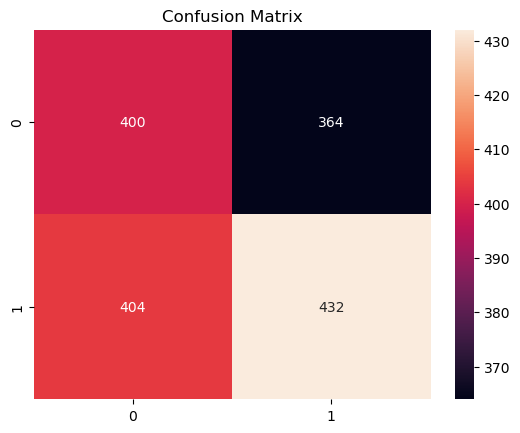

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()